In [1]:
# CSMODEL S01
# G25 - Monty Python and the Holy Bell Curve 
# Members: 
# Abogadie, Nina 
# De Gracia, Kaleela 
# Domingo, Stefan
# Jose, Yesha
# Perez, Jose 

# CSMODEL MCO1 
### Competitive Games and its Effect on Strategic Decision Making 



### Abstract
To succeed in competitive multiplayer games, players have to constantly be making several consequential decisions within a very short timeframe should they wish to succeed. This study therefore wishes to explore if higher skilled players exhibit better strategic decision making. To do so we shall be looking at data collected from PUBG, a popular battle royale style game where 100 players all must survive in an ever shrinking map aiming to be the last one alive. We have found that indeed, high ranking players in PUBG showcase strategies that require coordianted aggressive play with teammates which indicates that highly skilled players are able to communicate and strategise well with their teammates in order to win.



### Dataset Description:
[PUBG Match Deaths and Statistics](https://www.kaggle.com/datasets/skihikingkevin/pubg-match-deaths)     

This Dataset was collected from Kaggle containing the data of over 720,000 matches of PUBG. It contains both aggregate match data and death data. The data was collected from OP.GG a popular third party game data tracker for esports and competitive games. Due to the third party nature of the data source it is likely that the dataset does not contain all the possible variables that can be extracted from a PUBG match which means possible nuance and depth is ultimately lost. 

We will be using the following variables of the aggregate dataset, the variables wil be explained further below in the preprocessing section:\
party_size\
player_assists\
player_dbno\
player_dmg\
player_kills\
player_survive_time\
team_placement

Each row/observation in the dataset is a player with the each column as shown above representing the data of that player. Each row is therefore unique as even if the same player was recorded twice their survival time, placement, and even kills could have changed between matches.


We will be using the following variables of the death dataset, the variables will be explained further below in the preprocessing section:\
killer_name\
killed_by\
killer_placement\
killer_position_x\
killer_position_y\
time\
victim_position_x\
victim_position_y

Each row/observation in the dataset is a kill. The same player/killer can appear multiple times as they can have multiple victims in a single match.


### Main EDA questions

Given the data that we have access to these are our main EDA questions that we wish to answer:
* Is there a performance difference between squad, duo, and solo players?
* How do the top ranking teams play?
* What are the most common weapons/strategies used?

From there we can use the answers to these questions to tie back to strategic decision making.

# Importing python libraries to be used 


Pandas - main library used for creating and manipulating dataframes. 

Numpy -  used for statistical calculations. 

Seaborn - data visualization. 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as norm
#setting the size of figures to be displayed in the notebook
sns.set_theme(rc={"figure.figsize": (12, 6)})

# Loading datasets to be used

In [3]:
PUBG_death1_df = pd.read_csv("Datasets/PUBG_Match_Data/deaths/kill_match_stats_final_0.csv")
PUBG_death2_df = pd.read_csv("Datasets/PUBG_Match_Data/deaths/kill_match_stats_final_1.csv")
PUBG_death3_df = pd.read_csv("Datasets/PUBG_Match_Data/deaths/kill_match_stats_final_2.csv")
PUBG_agg_stats_df = pd.read_csv("Datasets/PUBG_Match_Data/aggregate/agg_match_stats_4.csv")

# Data Preprocessing

### Preprocessing aggregate match data

As a disclaimer, the PUBG dataset we are using gives the statistics for organizes its data into chunks of 5 categorized as the death statistics and the aggregate statistics. For the aggregate statistics 4 of the csv files exceeded the Git LFS file size limit Github allowed hence why only a size csv file is being used for exploring aggregate data. 

Aggregation data for PUBG matches includes match metadata such as teamIDs, team rankings, kills, survival time, etc. The baseline metric we will be using to measure success is a team's placement at the end of a match.

Our main questions then pertain to how certain factors like survival time and total kills correlate to team placement, additionally since squad size is also recorded we can investigate how collaboration and the lack thereof correlates with success/team placement. 

Beginning preprocessing we drop all rows containing null values as well as columns that we won't be needing for analysis. 

In [4]:
PUBG_agg_stats_df = PUBG_agg_stats_df.dropna()
PUBG_agg_stats_df = PUBG_agg_stats_df.drop(columns=['date','game_size','match_id','match_mode','team_id','player_name'])

Next we convert the "player_survive_time" column to be measured in minutes rather than seconds.

In [5]:
PUBG_agg_stats_df['player_survive_time'] = PUBG_agg_stats_df['player_survive_time']/60
PUBG_agg_stats_df['player_survive_time'] = np.round(PUBG_agg_stats_df['player_survive_time'], decimals=2)

Now we verify the values of the survival time column. As shown below, there are several extremely high outlier values within the "player_survive_time" column. We attributed these values as encoding errors as they are statistically impossible.

In [6]:
print(PUBG_agg_stats_df['player_survive_time'].sort_values(ascending=False).head(10))

8912397     1.060804e+09
8912396     1.060804e+09
8912398     1.060804e+09
10549720    1.060780e+09
10549719    1.060780e+09
10549725    1.060780e+09
10549674    1.060780e+09
10549677    1.060780e+09
10549678    1.060780e+09
10549690    1.060780e+09
Name: player_survive_time, dtype: float64


To address this we decided to drop these rows entirely based on the 99th percentile value

In [7]:
max = PUBG_agg_stats_df['player_survive_time'].quantile(0.99) #this returns 32.24 minutes which is a reasonable number as the average PUBG match does last around 20-30 minutes
PUBG_agg_stats_df = PUBG_agg_stats_df[PUBG_agg_stats_df['player_survive_time'] < max]

Next we verify the team placements to ensure there are no odd values and sure enough there are. Team placement in PUBG only goes as low as 1 as that indicates they are the winner of the match, therefore having a placement of 0 is impossible. Thus these rows have to be removed.

In [8]:
print(PUBG_agg_stats_df['team_placement'].sort_values().head(10))

10720613    0
10720673    0
10720614    0
2259928     1
2259927     1
2259926     1
2259855     1
2259854     1
2259853     1
8500604     1
Name: team_placement, dtype: int64


In [9]:
PUBG_agg_stats_df = PUBG_agg_stats_df.query('team_placement != 0')

### Preprocessing death match data


Another disclaimer before proceeding, as mentioned at the beginning of the preprocessing of the aggregate data, the death data was split across 5 differing csv files. All files combined totaled to over 10GB of data which became unwieldy to process as we frequently ran into MemoryErrors due to hardware limitations. As such we have chosen to only process 3 of the original 5 files.

Death data for PUBG includes data such as the killer and victim's positions on the map, what the cause of death was, who the killer and victim were, etc.

Since the death match data is split across multiple files our first step in preprocessing is combining all the dataframes into one big dataframe. All the files are formatted the exact same so we can use the pandas concat function to quickly stack them ontop of each other.

In [9]:
PUBG_death_df = pd.concat([PUBG_death1_df,PUBG_death2_df,PUBG_death3_df])

Next we proceed by dropping rows that contain empty values which are quite numerous since players dying via in game mechanics like drowning or being outside the safe zone leave columns 2-5 empty as there is no player data to encode as the killer. We then also drop other columns we don't need such as match metadata and player names.

In [10]:
PUBG_death_df = PUBG_death_df.dropna()
PUBG_death_df = PUBG_death_df.drop(columns=['map','match_id','victim_name','victim_placement'])

Next we create a new column that calculates the distance between a killer and their victim. We can use the euclidean distance formula since we are given x and y coordinates. We shall also round this resulting distance to 2 decimal places for the sake of readability.

In [11]:
dist = np.round(np.sqrt((PUBG_death_df['killer_position_x'] - PUBG_death_df['victim_position_x'])**2 + 
                        (PUBG_death_df['killer_position_y'] - PUBG_death_df['victim_position_y'])**2), 
                        decimals=2)

Before proceeding we first inspect the data within the new column and see that some kills that are encoded are seemingly impossible as they span farther than the actual map's length which is 800,000cm or 8km. When appending this series into the main dataframe we can see these kills are impossible, take for example killing someone with a punch over 8km away. Whether these are hackers, encoding errors, or the game misattributing a kill to the wrong player, these data points are unusable.

In [12]:
PUBG_death_df['kill_distance'] = dist

PUBG_death_df[PUBG_death_df['kill_distance'] > 800000][
    ['killer_name', 'killed_by', 'killer_position_x', 'killer_position_y', 'victim_position_x', 'victim_position_y','kill_distance']
].head(15)

,killer_name,killed_by,killer_position_x,killer_position_y,victim_position_x,victim_position_y,kill_distance
5,xuezhiqian717,Punch,721944.4,359575.3,0.0,0.0,806534.63
15,xuezhiqian717,Punch,725042.3,361510.1,0.0,0.0,810170.28
53,xuezhiqian717,Punch,725012.6,361189.7,0.0,0.0,810000.78
396,JIUXIE-NB,M416,423640.8,712687.2,0.0,0.0,829092.62
453,JIUXIE-NB,M416,423694.8,712692.4,0.0,0.0,829124.68
2414,Dysteny,Punch,571319.7,630848.8,0.0,0.0,851103.05
3506,PrPrPrPr123,P1911,598558.3,582883.3,0.0,0.0,835478.89
4066,Fastdtodo,Punch,581497.3,615052.4,0.0,0.0,846421.03
4082,Fastdtodo,Punch,579321.6,613074.4,0.0,0.0,843489.03
4089,Fastdtodo,Punch,580189.4,615772.3,0.0,0.0,846046.85


Another oddity that we needed to consider is self kills or kills where the kill_distance is exactly 0.0. As seen below a majority of these are due to grenades which make sense as people can blow themselves up with their own grenades by accident. Much like the previous example above, these data points are not needed for our use case.

In [13]:
PUBG_death_df[PUBG_death_df['kill_distance'] == 0][
    ['killer_name', 'killed_by','killer_position_x', 'killer_position_y', 'victim_position_x', 'victim_position_y','kill_distance']
].head(15)

,killer_name,killed_by,killer_position_x,killer_position_y,victim_position_x,victim_position_y,kill_distance
0,KrazyPortuguese,Grenade,657725.10,146275.2,657725.10,146275.2,0.0
57,nide2Bxiaojiejie,Grenade,90925.14,722112.9,90925.14,722112.9,0.0
111,#unknown,Win94,315037.20,357087.6,315037.20,357087.6,0.0
120,#unknown,Grenade,510511.30,426254.8,510511.30,426254.8,0.0
175,Guitar18,Grenade,534755.50,263761.0,534755.50,263761.0,0.0
423,xvwangming,Grenade,412525.50,271518.9,412525.50,271518.9,0.0
425,CPjj,Grenade,415035.60,481148.6,415035.60,481148.6,0.0
497,dsadwada,Falling,426700.80,217050.3,426700.80,217050.3,0.0
522,AZ7548784,Grenade,264733.60,551562.3,264733.60,551562.3,0.0
689,wijnmhusb,Hit by Car,295475.10,324489.3,295475.10,324489.3,0.0


A lot of these outliers occur when either the victim or killer is positioned exactly at (0,0) therefore we will be removing all entries that contain those exact coordinates for either the killer or victim positions. We can safely use the (0,0) position as our indicator of a bad data point because due to the size of the player models it is almost impossible for a person to be standing at exact the (0,0) axis. While we're at it, we shall also remove all entries where the kill distance is exactly 0.

In [14]:
PUBG_death_df = PUBG_death_df.query('killer_position_x != 0 and killer_position_y != 0 or victim_position_x != 0 and victim_position_y != 0')

In [15]:
PUBG_death_df = PUBG_death_df.query('kill_distance != 0.0')

Now we can convert the data into meters which is simply applying a scalar divison by 100 to the entire column.

In [16]:
PUBG_death_df['kill_distance'] = PUBG_death_df['kill_distance'] / 100
PUBG_death_df['kill_distance'] = np.round(PUBG_death_df['kill_distance'], decimals=2 )

Now we can do a final check through of the kill distance to see if any outliers remain. 

In [17]:
PUBG_death_df['kill_distance'].describe()

count    3.578580e+07
mean     2.069347e+02
std      1.004490e+03
min      0.000000e+00
25%      5.210000e+00
50%      1.749000e+01
75%      5.745000e+01
max      1.080040e+04
Name: kill_distance, dtype: float64

We can still see some outliers remain in the data since the highest kill distance is 10,800.04m which is extremely unlikely as the longest ranged snipers in the game have an effective range of only 700m. We can do what we did earlier and cap the max kill entries based on a quantile value.

In [18]:
max = PUBG_death_df['kill_distance'].quantile(0.97) # this gives us a distance of 505.78m which is an acceptable max range.
PUBG_death_df = PUBG_death_df[PUBG_death_df['kill_distance'] < max]

With the kill distance calculated and cleaned we can then safely drop the positional data as we won't be needing it any longer.

In [19]:
PUBG_death_df = PUBG_death_df.drop(columns=['killer_position_x','killer_position_y','victim_position_x','victim_position_y'])

Now we can also convert the time into minutes

In [20]:
PUBG_death_df['time'] = PUBG_death_df['time'] / 60
PUBG_death_df['time'] = np.round(PUBG_death_df['time'], decimals=2 )

# Exploratory Data Analysis

### Exploratory Data Analysis for aggregate match data

Our first relationship to investigate is if there exists a correlation between party size (solo, duo, squad) and the survival time of a player i.e. does playing with/without people correlate to how long they last in a game?

In [21]:
print(PUBG_agg_stats_df['player_survive_time'].corr(PUBG_agg_stats_df['party_size']))

0.07474940535994508


As indicated by the correlation calculation above, there exists an extremely weak correlation between the two, graphing them into a box plot we can investigate the relationship more clearly.

<Axes: xlabel='party_size', ylabel='player_survive_time'>

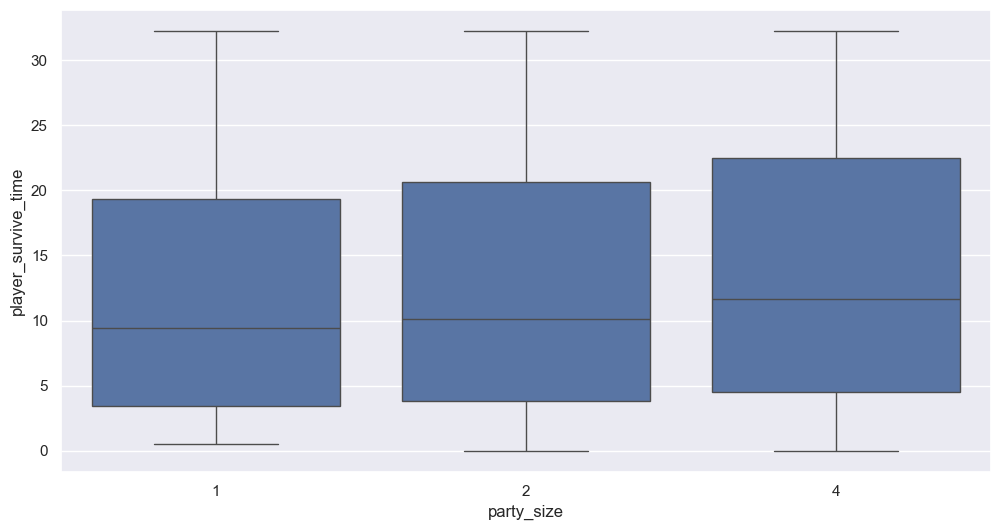

In [22]:
sns.boxplot(data=PUBG_agg_stats_df, x='party_size', y='player_survive_time')

The visualization above explains the relationship more clearly, all party sizes share the same relative variance with their upper and lower whiskers relatively similar. It is in the upper quartile where we see the largest difference with sqauds having the largest range indicating the players on average survive longer when playing in a team of 4 as opposed to playing with a partner or solo. 

We can also estimate that the average survival time of a player regardless of team size lies somewhere between 10-15 minutes. This is corroborated by the calculated mean below.

In [23]:
print(np.round(np.mean(PUBG_agg_stats_df['player_survive_time']), decimals=2))

12.91


Moving forward we shall look into how team placement correlates with other variables instead. Beginning with party size again. We use the same pearson correlation formula and find a moderate negative correlation between the two. 

In [24]:
print(PUBG_agg_stats_df['team_placement'].corr(PUBG_agg_stats_df['party_size']))

-0.5881616810489296


This indicates that the bigger the squad size the lower that team ranks. This is a good observation as it indicates that playing with other people could help in placing higher on the leaderboard by the end of the game.

<Axes: xlabel='party_size', ylabel='team_placement'>

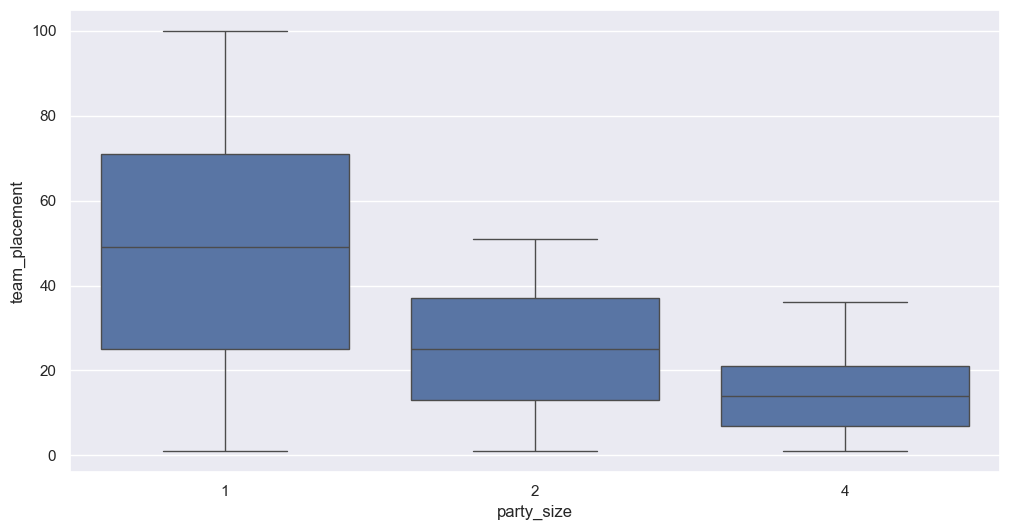

In [25]:
sns.boxplot(data=PUBG_agg_stats_df, x='party_size', y='team_placement')

The box plot above shows an even clearer picture of this correlation. We can see that even though each size's lower whiskers are identical, meaning all team sizes have achieved first place, it is in their upper whiskers where we can see the largest difference. Solo players are almost always the first to die e.g. obtain a higher team placement while duos at worst reach the top 50s with squads being the most performant as the lowest a team of had placed being somewhere in the top 40. Overall what this graph shows us is that while success can be achieved by any team, it is the squads who manage to place in the top 20 on average.

Next we shall investigate how aggressive the top 20 placing teams are via measuring their average damage dealt and kills. To do so we shall be passing on a smaller dataframe which only contains teams who placed within the top 20, we then use this the pivot table function in order to calculate the average damage per combination of factors e.g. what is the average damage dealt by duos place within 2nd place?

We then plot this dataframe into a heatmap and below is the resulting plot.

<Axes: xlabel='team_placement', ylabel='party_size'>

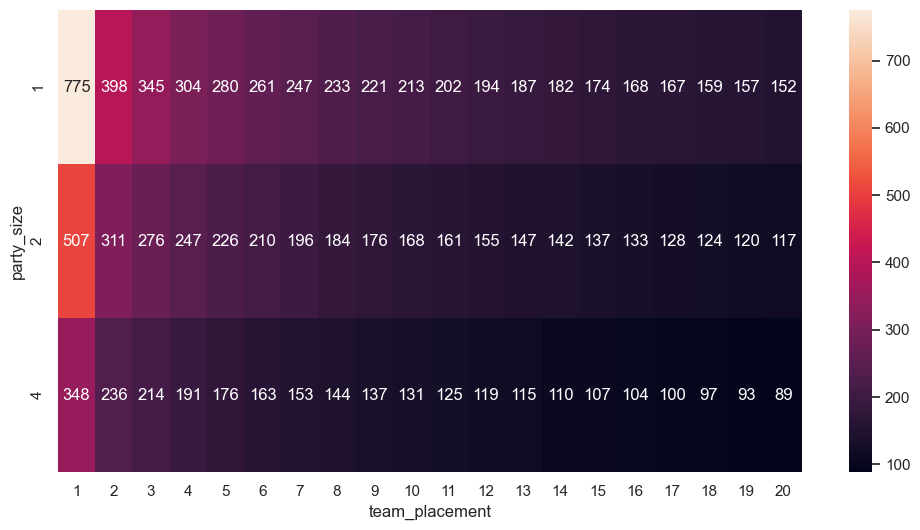

In [26]:
top = PUBG_agg_stats_df[PUBG_agg_stats_df['team_placement'] <= 20]
heat = top.pivot_table(index='party_size',columns='team_placement',values='player_dmg',aggfunc='mean')

sns.heatmap(heat, annot=True, fmt='.0f')

Based on the heatmap above, aggressive play is a highly effective strategy. We can clearly first place averages a significant jump in damage compared to the incremental damage increase we see from 20th to 2nd place.

Finally we investigate how collaborative the top 20 teams via the "player_dbno" value. In PUBG, if you are playing in duos or squads, you are not immediately eliminated when reaching 0 health. Instead you enter a "Down But Not Out" state where you are unable to shoot or melee but can crawl around and be rescued by a teammate. The "player_dbno" value tracks how many times a player has entered said state. 

The general idea behind investigating this relationship is we want to see on average how many times a player who was in a team that made it in the top 20 was downed and subsequently saved by another teammate indicating collaboration and teamwork. Of course we shall be ignoring all solo top placers for this.

<Axes: xlabel='team_placement', ylabel='party_size'>

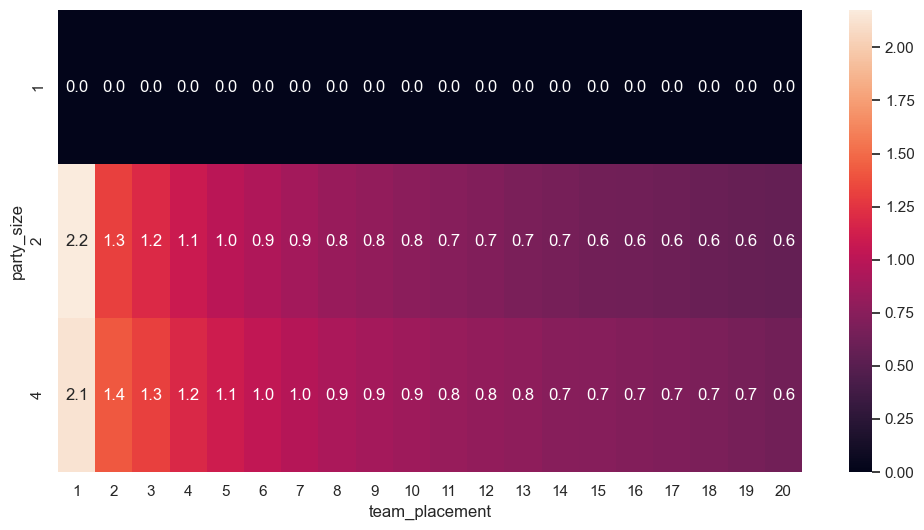

In [27]:
top = PUBG_agg_stats_df[PUBG_agg_stats_df['team_placement'] <= 20]
heat = top.pivot_table(index='party_size',columns='team_placement',values='player_dbno',aggfunc='mean')

sns.heatmap(heat, annot=True, fmt='.01f')

As indicated by the plot above, higher ranking teams average more "dbno's" which indicates that teammates are consistently looking after and rescuing each other from failed engagements. This shows that collaboration coupled with aggression from the previous plot are part of a winning strategy.

### Exploratory Data Analysis for death match data

The first thing we would like to investigate regarding death data is the most common causes of death within PUBG. To do so we take the 10 most frequently occuring values from the "killed_by" column and plot them into a histogram.

<Axes: xlabel='killed_by', ylabel='count'>

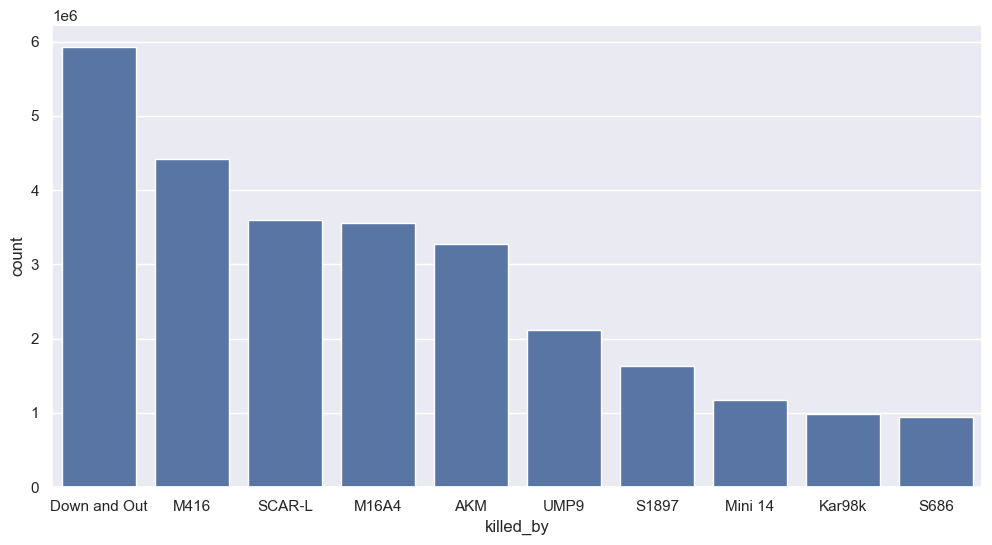

In [28]:
top10 = PUBG_death_df['killed_by'].value_counts().nlargest(10).index

filtered10 = PUBG_death_df[PUBG_death_df['killed_by'].isin(top10)]

sns.countplot(filtered10 , x='killed_by', order=top10)

For reference the scientific notation located at the top left "1e6" is the scale with which count is being rendered at so these numbers are in intervals in the millions. The most common cause of death is "Down and Out" which is not a weapon more so death caused by being in the "Down But Not Out" state that was discussed earlier so we can safely disregard it. That being the case, the most common deaths are caused by midrange rifle weapons like the M416 and SCAR-L.

Next we'll be looking at kill distance to determine how far away killers are from their victims. Ideally we should see most kills happen within 100m.

<Axes: xlabel='kill_distance', ylabel='Count'>

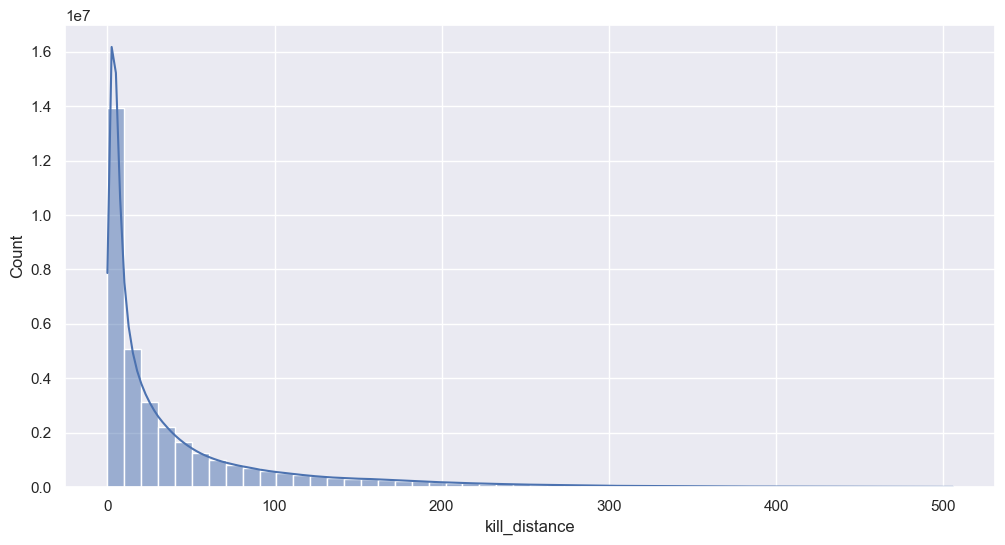

In [29]:
sns.histplot(PUBG_death_df['kill_distance'], bins=50, kde=True)

This corroborates with the previous plot, we see most kills happen within 50 meters and skewing towards closer range kills. This indicates most engagements happening in close ranges where positioning and movement would be key to success. 

Now we will look at how many kills players who have entered the top 10 rankings accrue over the course of a game.

<Axes: xlabel='killer_placement', ylabel='count'>

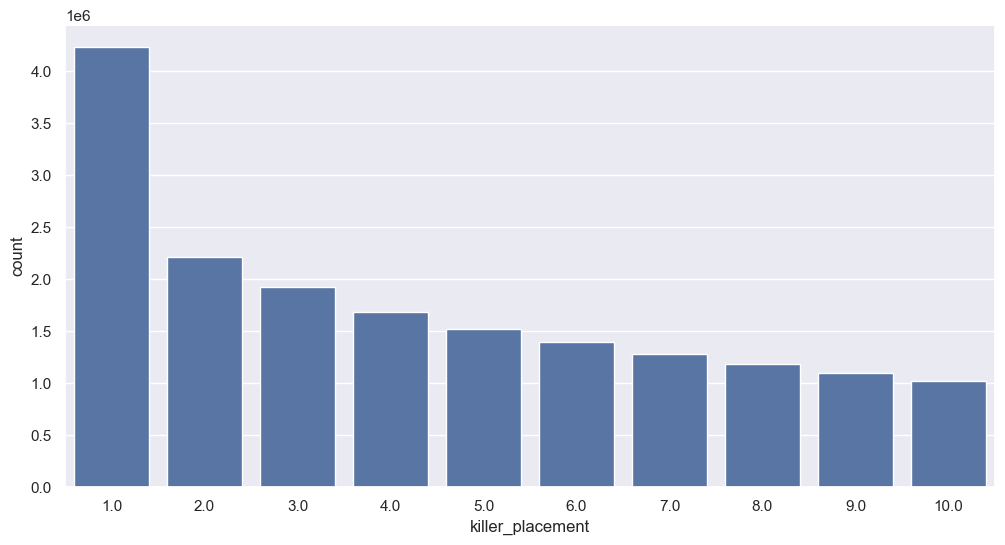

In [30]:
tkill10 = PUBG_death_df[PUBG_death_df['killer_placement'] <= 10]

sns.countplot(tkill10, x='killer_placement')

As seen earlier first place players always have significantly more kills than 2nd place. Again emphasizing aggression as the ideal strategy

<Axes: xlabel='time', ylabel='Count'>

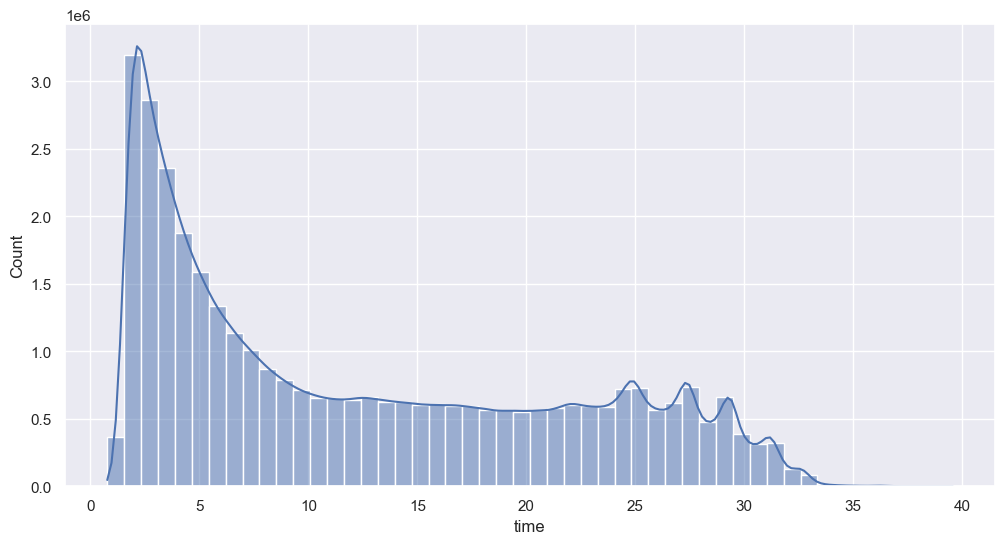

In [31]:
sns.histplot(PUBG_death_df['time'], bins=50, kde=True)

We can further see this in this graph of when most kills happen in game which is near the beginning which further supports the aggressive playstyle to immediately thin out competitors.

# Statistical Testing

### Bayesian Inference

To begin with the statistical testing we first conduct a Bayesian Inference test to gauge the probability of certain team sizes placing in the top 10 rankings of a PUBG match.

First is to convert our team_placement column into some boolean 0 or 1 value to represent if a team placed in the top 10 or not. We simply apply a quick logic statement to the entire column.

In [32]:
PUBG_agg_stats_df['top10'] = (PUBG_agg_stats_df['team_placement'] <= 10).astype(int)

In [33]:
PUBG_agg_stats_df['top10']

0           0
1           1
2           0
3           0
4           0
           ..
11993480    0
11993481    0
11993482    0
11993483    0
11993484    0
Name: top10, Length: 11855802, dtype: int64

Next we must start with an uninformed or objective prior (Beta (1,1)) since we want our new observed data to be the main influence in the new posterior distribution. 

In [34]:
alpha_prior, beta_prior = 1, 1

Now we can compute for the probability each party size will place in the top 10.

In [35]:
#dict to store party size and their alpha,beta posteriors
posteriors = {}

#loop to iterate over each party_size (1,2,4) and computes for the posterior per size
for size in sorted(PUBG_agg_stats_df['party_size'].unique()):
    group = PUBG_agg_stats_df[PUBG_agg_stats_df['party_size'] == size]
    successes = group['top10'].sum()
    trials = len(group)
    failures = trials - successes

    # Beta-Binomial conjugacy: posterior = Beta(alpha_prior + successes, beta_prior + failures)
    alpha_post = alpha_prior + successes
    beta_post = beta_prior + failures
    posteriors[size] = (alpha_post, beta_post)

    mean = alpha_post / (alpha_post + beta_post)

    print(f"Party size {size}: n={trials}, top10={successes}")
    print(f"  Posterior mean top10 rate: {mean:.4f}\n")

Party size 1: n=2483896, top10=249034
  Posterior mean top10 rate: 0.1003

Party size 2: n=3805250, top10=776346
  Posterior mean top10 rate: 0.2040

Party size 4: n=5566656, top10=2090970
  Posterior mean top10 rate: 0.3756



The results shown above show a clear trend of how party size correlates with overall placement. Solo players will have a 10% chance to break into the top 10 teams, duo players have more than double the likelihood with a 20% chance to break into the top 10 teams and sqauds having over triple the likelihood with a 38% chance.

We can further observe this relationship by measuring the probability of how much more likely a party composition would rank over each other.

In [36]:
n_samples = 100000

samples = {
    size: np.random.beta(a, b, n_samples)
    for size, (a, b) in posteriors.items()
}

sizes = sorted(posteriors.keys())
for i in range(len(sizes)):
    for j in range(i+1, len(sizes)):
        s1, s2 = sizes[i], sizes[j]
        prob = np.mean(samples[s2] > samples[s1])
        print(f"P(party_size={s2} has higher top10 rate than party_size={s1}) = {prob:.4f}")

P(party_size=2 has higher top10 rate than party_size=1) = 1.0000
P(party_size=4 has higher top10 rate than party_size=1) = 1.0000
P(party_size=4 has higher top10 rate than party_size=2) = 1.0000


Again, these results corroborate with our findings in our EDA. Having more players in your team gives you a 100% better chance to place higher in the top 10.

### ANOVA 


For the ANOVA test, we are determining if there is a significant difference in performance between the 3 types in party_size (solo, duo and full squad) and the player_survive_time and team placement together. To do this, we need to group the dataframe based on their party size here. For this, there will be one set related to the player_survive_time based on the party_size column and another set related to the team_placement based on the same column.

In [46]:
# Set 1 = Player Survival Time
solo_time = PUBG_agg_stats_df[PUBG_agg_stats_df["party_size"] == 1]["player_survive_time"]
duo_time = PUBG_agg_stats_df[PUBG_agg_stats_df["party_size"] == 2]["player_survive_time"]
squad_time = PUBG_agg_stats_df[PUBG_agg_stats_df["party_size"] == 4]["player_survive_time"]
# Set 2 = Team Placement
solo_place = PUBG_agg_stats_df[PUBG_agg_stats_df["party_size"] == 1]["team_placement"]
duo_place = PUBG_agg_stats_df[PUBG_agg_stats_df["party_size"] == 2]["team_placement"]
squad_place = PUBG_agg_stats_df[PUBG_agg_stats_df["party_size"] == 4]["team_placement"]

Now that we have our sets ready, we have to state our null and alternative hypotheses.

These hypotheses represents if there is a significant difference between the player's survival time and the different party sizes they joined during a match.
- $H_0$: $\mu_{solo} = \mu_{duo} = \mu_{squad}$ (There is no difference on the player's survival time and the party size they joined)
- $H_A$: At least one of the means varies (There is a difference on the player's survival time and the party size they joined)

These hypotheses represents if there is a significant difference between the player's team placement and the different party sizes they joined during a match.
- $H_0$: $\mu_{solo} = \mu_{duo} = \mu_{squad}$ (There is no difference on the player's team placement and the party size they joined)
- $H_A$: At least one of the means varies (There is a difference on the player's team placement and the party size they joined)


Then, we compute for the test statistic, the f-statistic value, and the p-value using the f_oneway ANOVA command from scipy.stats. This would aid in determing our decision in whether to reject the null hypothesis or not.

In [48]:
f_stat_time, p_value_time = norm.f_oneway(solo_time, duo_time, squad_time)
f_stat_place, p_value_place = norm.f_oneway(solo_place, duo_place, squad_place)

print(f"F-statistic (Player Survival Time) = {f_stat_time:.4f}")
print(f"p-value (Player Survival Time) = {p_value_time:.4f}")
print(f"F-statistic (Team Placement) = {f_stat_place:.4f}")
print(f"p-value (Team Placement) = {p_value_place:.4f}")

F-statistic (Player Survival Time) = 33415.9357
p-value (Player Survival Time) = 0.0000
F-statistic (Team Placement) = 4083577.9387
p-value (Team Placement) = 0.0000


Assuming that our significance level is 0.05, we can see that the p-values from both hypotheses are 0.0000. Since it is lower than the significance level, the final decision is that we both reject the null hypotheses and accept the alternative. Therefore, there is strong statistical evidence that the party size has a significant effect on determining the player's survival time and placement on the round. 

# Association Rule Mining

For data mining, we will use Association Rule Mining as our data mining technique as it is the most relevant to our topic. By grouping `killed_by` or the weapon used by the player and `killer_name`, we can identify the recurring weapon combinations among the top 20 ranking players. Recurring combinations with a high confidence level represent consistent strategic preferences during matches rather than isolated weapon selections.  

Because weapon choice is an important part of the player's strategy in-game, frequent associations among player and weapon type is evidence of a common gameplay strategy adopted by a high-performing competitive player.  

To begin, we must get the top 20 ranking players. We will filter out players that are missing or `#unknown`.

In [37]:
top20 = PUBG_death_df["killer_name"].value_counts().head(20).index

top20 = top20[top20 != "#unknown"]

top20 

Index(['JZalan', 'hzxiaobin', 'GhostDL', 'VanThang', 'Ashbur_', 'feitengdedan',
       'siliymaui125', 'Roobydooble', 'LostInVegas', 'idzhennanqu', 'sora3',
       'GoAheadTry2Run', 'Phara', 'zzTo', 'ddldidd', 'jimmy0572', 'porchmonky',
       'HolyCoW', 'dawsonTsui'],
      dtype='object', name='killer_name')

Because the `killed_by` column includes all possible causes of player death that may not caused by another player's direct interference (Falling from a high place, being caught in the RedZone artillery airstrike, being hit by a vehicle, etc.), we will filter those out to create a consolidated list of weapon names. 

In [38]:
weapon_names = PUBG_death_df['killed_by'].unique()

weapon_names

array(['SCAR-L', 'S686', 'Down and Out', 'M416', 'AKM', 'Punch', 'P92',
       'Win94', 'M16A4', 'S12K', 'Hit by Car', 'death.WeapSawnoff_C',
       'Kar98k', 'Tommy Gun', 'S1897', 'Bluezone', 'Grenade', 'Micro UZI',
       'P1911', 'SKS', 'UMP9', 'Mini 14', 'P18C', 'Machete', 'Groza',
       'Crossbow', 'Drown', 'Vector', 'R1895', 'Falling', 'M249', 'Uaz',
       'M24', 'VSS', 'Pan', 'AWM', 'Dacia', 'DP-28', 'Mk14',
       'death.Buff_FireDOT_C', 'Crowbar', 'R45', 'Sickle',
       'Motorbike (SideCar)', 'AUG', 'Van', 'Motorbike', 'Pickup Truck',
       'death.ProjMolotov_DamageField_C', 'Buggy', 'Aquarail', 'Boat',
       'RedZone', 'death.ProjMolotov_C', 'death.PG117_A_01_C'],
      dtype=object)

In [39]:
invalid_weapons = ['Down and Out', 'Hit by Car', 'death.WeapSawnoff_C', 'Drown', 'Falling', 'death.Buff_FireDOT_C', 'Motorbike (SideCar)', 'Van', 'Motorbike', 'Pickup Truck', 'death.ProjMolotov_DamageField_C', 'Buggy', 'Aquarail', 'Boat', 'RedZone', 'death.ProjMolotov_C', 'death.PG117_A_01_C']

PUBG_death_df = PUBG_death_df[~PUBG_death_df["killed_by"].isin(invalid_weapons)]

Then, we will filter `PUBG_death_df` to only the top 20 ranked players.  

In [40]:
top20_df = PUBG_death_df[PUBG_death_df["killer_name"].isin(top20)]

Now, we can group the weapons used by the top 20 players. 

In [41]:
weapon_group = top20_df.groupby("killer_name")["killed_by"].apply(lambda x: sorted(set(x))) 

weapon_group

killer_name
Ashbur_           [AKM, AWM, Bluezone, Crossbow, Crowbar, Dacia,...
GhostDL           [AKM, AUG, AWM, Bluezone, Crowbar, DP-28, Daci...
GoAheadTry2Run    [AKM, Bluezone, Crossbow, DP-28, Dacia, Grenad...
HolyCoW           [AKM, AWM, Bluezone, Dacia, Grenade, Groza, Ka...
JZalan            [AKM, AWM, Bluezone, DP-28, Grenade, Groza, Ka...
LostInVegas       [AKM, AWM, Bluezone, Crossbow, DP-28, Grenade,...
Phara             [AKM, AUG, Bluezone, DP-28, Dacia, Grenade, Gr...
Roobydooble       [AKM, Crossbow, Dacia, Grenade, Kar98k, M16A4,...
VanThang          [AKM, AUG, AWM, Crowbar, DP-28, Grenade, Kar98...
dawsonTsui        [AKM, AWM, Bluezone, Crowbar, Dacia, Grenade, ...
ddldidd           [AKM, AWM, Bluezone, Crossbow, DP-28, Grenade,...
feitengdedan      [AKM, AWM, Bluezone, Crossbow, Dacia, Grenade,...
hzxiaobin         [AKM, AWM, Bluezone, Dacia, Grenade, Groza, Ka...
idzhennanqu       [AKM, Bluezone, Crossbow, Grenade, Groza, Kar9...
jimmy0572         [AKM, Bluezone, DP

##### One-Hot Encoding

In order to apply Association Rule Mining to `weapons_group`, we will conduct one-hot encoding on the weapon types. 

In [ ]:
weapon_ohe = pd.get_dummies(top20_df["killed_by"], dtype=int)

Next, we will add `killer_names` to the one-hot encoded weapons. 

In [ ]:
weapon_ohe["killer_name"] = top20_df["killer_name"]

Then, we will create a new DataFrame with one row per `killer_name` and weapons used. 

In [ ]:
row_df = weapon_ohe.groupby("killer_name").max() 

After One-Hot Encoding, the resulting DataFrame `row_df` can now be used to perform Association Rule Mining. 

##### Association Rule Mining Functions